In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.linear_model import LassoCV, RidgeCV
from xgboost import XGBRegressor, XGBClassifier
import shap

import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats

from scripts.preprocess import load_preprocessed_data

PRIMARY = "#355C73"
ACCENT  = "#5F7F76"
RISK    = "#B5614C"

c:\Users\LENOVO\machine learning project\Machine-Learning-810161\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Feature Engineering

Two parallel targets from the same feature matrix:
- **Regression** â†’ `profit` (â‚¬): where is value created or destroyed?
- **Classification** â†’ `is_loss` (profit < 0): will this task lose money?

### Design Decisions
1. `rework_ratio` (rework_hours / hours_spent) captures efficiency erosion, normalised across task sizes. Capped at 1.0 for the 67 ambiguous rows where rework > hours.
2. `billable_hours` dropped because collinear with `hours_spent` and downstream of pricing.
3. `revenue`, `cost` excluded because it's a direct components of `profit` (leakage).

In [2]:
df = load_preprocessed_data("data/ai_productivity_dataset_final.csv")

In [3]:
REG_TARGET = "profit"
CLF_TARGET = "is_loss"

In [4]:
# columns excluded from features (leakage, identifiers, collinear, or target-derived)
LEAK_COLS = ["revenue", "cost", "billable_hours", "is_loss", "profit"]
ID_COLS = ["task_id", "client", "project_id", "created_by", "jira_ticket"]
DATE_COLS = ["created_at", "delivered_at", "updated_at"]
META_COLS = ["task_status", "workflow_stage", "content_version"]
REDUNDANT_COLS = ["ai_assisted", "legacy_ai_flag", "rework_hours"]   # absorbed by ai_usage_pct / rework_ratio
DROP_COLS = LEAK_COLS + ID_COLS + DATE_COLS + META_COLS + REDUNDANT_COLS

ORDINAL_COLS = ["seniority", "deadline_pressure", "client_tier"]
ORDINAL_CATEGORIES = [
    ["junior", "mid", "senior"],
    ["low", "medium", "high"],
    ["low", "mid", "high"],
]

NOMINAL_COLS = ["pricing_model", "task_type", "team"]

In [5]:
def add_rework_ratio(df):
    """Fraction of effort spent on rework, capped at 1.0 for ambiguous rows."""
    df = df.copy()
    df["rework_ratio"] = (df["rework_hours"] / df["hours_spent"]).clip(upper=1.0)
    return df


def select_features(df):
    """Drop leakage / id / metadata columns, return feature-only DataFrame."""
    return df.drop(columns=[c for c in DROP_COLS if c in df.columns])


def identify_column_groups(X):
    """Split columns into passthrough-numeric, ordinal, and nominal groups."""
    passthrough = [c for c in X.columns if c not in ORDINAL_COLS + NOMINAL_COLS]
    return passthrough, ORDINAL_COLS, NOMINAL_COLS


def build_preprocessor(passthrough_cols, ordinal_cols, nominal_cols):
    """ColumnTransformer: passthrough numerics, ordinal-encode ordered cats, one-hot nominals."""
    return ColumnTransformer(
        transformers=[
            ("num", "passthrough", passthrough_cols),
            ("ord", OrdinalEncoder(categories=ORDINAL_CATEGORIES), ordinal_cols),
            ("nom", OneHotEncoder(drop="first", sparse_output=False, dtype=int), nominal_cols),
        ],
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")

In [6]:
df = add_rework_ratio(df)
y_reg, y_clf = df[REG_TARGET], df[CLF_TARGET]
X_raw = select_features(df)

mask = X_raw.notna().all(axis=1) & y_reg.notna()
X_raw, y_reg, y_clf = X_raw[mask].reset_index(drop=True), y_reg[mask].reset_index(drop=True), y_clf[mask].reset_index(drop=True)

passthrough, ordinal, nominal = identify_column_groups(X_raw)
preprocessor = build_preprocessor(passthrough, ordinal, nominal)
X = preprocessor.fit_transform(X_raw)

print(f"Feature matrix: {X.shape[0]} rows Ã— {X.shape[1]} features")
print(f"Regression target (profit):  mean={y_reg.mean():.0f}â‚¬, std={y_reg.std():.0f}â‚¬")
print(f"Classification target (is_loss): {y_clf.mean():.1%} positive rate")

Feature matrix: 2765 rows Ã— 25 features
Regression target (profit):  mean=357â‚¬, std=901â‚¬
Classification target (is_loss): 24.6% positive rate


---

## OLS Baseline

Before training non-linear models, we establish an interpretable baseline using OLS regression. This lets us read off coefficients with standard errors and confidence intervals, a statistical sanity check and a benchmark against which the RF and XGBoost results can be compared.

Reference categories: `pricing_model = fixed`, `task_type = ad`, `team = Content`.

In [7]:
ORDINAL_MAPS = {
    col: {cat: i for i, cat in enumerate(cats)}
    for col, cats in zip(ORDINAL_COLS, ORDINAL_CATEGORIES)
}

def prepare_ols_frame(X_raw, y):
    """
    Build a regression-ready dataframe from the raw feature frame.
    Ordinal columns are mapped to integers; nominal columns stay as strings
    so the formula API handles dummy creation via C().
    """
    df_ols = X_raw.copy()
    df_ols["profit"] = y.values
    for col, mapping in ORDINAL_MAPS.items():
        df_ols[col] = df_ols[col].map(mapping)
    return df_ols.dropna()

df_ols = prepare_ols_frame(X_raw, y_reg)
print(f"OLS dataframe: {df_ols.shape[0]} rows Ã— {df_ols.shape[1]} columns")

OLS dataframe: 2765 rows Ã— 18 columns


### Baseline OLS

All controls included, no interaction terms. Reference categories: `pricing_model = fixed`, `task_type = ad`, `team = Content`.

In [8]:
BASELINE_FORMULA = """
profit ~ ai_usage_pct
       + hours_spent
       + rework_ratio
       + task_complexity_score
       + brief_quality_score
       + outcome_score
       + errors
       + revisions
       + sla_days
       + scope_change_flag
       + seniority
       + deadline_pressure
       + client_tier
       + C(pricing_model, Treatment(reference='fixed'))
       + C(task_type,     Treatment(reference='ad'))
       + C(team,          Treatment(reference='Content'))
"""

ols_baseline = smf.ols(BASELINE_FORMULA, data=df_ols).fit(cov_type="HC3")
print(ols_baseline.summary())

                            OLS Regression Results                            
Dep. Variable:                 profit   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     19.59
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           3.61e-77
Time:                        16:41:09   Log-Likelihood:                -22565.
No. Observations:                2765   AIC:                         4.518e+04
Df Residuals:                    2740   BIC:                         4.533e+04
Df Model:                          24                                         
Covariance Type:                  HC3                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

#### Baseline results

**Model fit:** RÂ² = 0.115, Adj RÂ² = 0.108. The model explains ~11% of the variance in profit. Profit at the task level is noisy; the model is not a prediction tool but a mechanism detector. The F-statistic (19.6, p < 0.001) confirms the variables are jointly significant.


---

**Significant findings (p < 0.05):**

- **Pricing model is the biggest lever.** Compared to a fixed-price contract, an hourly contract earns **â‚¬254 less profit** on an identical task - same team, same complexity, same AI usage. When AI makes the team faster on hourly, the client just pays fewer hours and keeps the saving. A value-based contract does the opposite: it earns **â‚¬286 more** than fixed, because the price is set by the outcome's worth, not the time spent. Fixing the contract type is worth more than any other single action.

- **AI usage helps, but moderately.** Going from 0% to 100% AI on a task adds **~â‚¬222 profit**. In practice: moving from 25% to 75% AI adds roughly **â‚¬111**. The effect is real (p = 0.015) but smaller than the pricing model effect. AI helps - but the wrong contract type erases the benefit entirely.

- **Complex tasks are more profitable.** Each step up the complexity scale (1 to 5) adds **â‚¬111 to profit**. Complex tasks justify higher rates and carry more margin. A complexity-4 task is expected to earn â‚¬222 more than a complexity-2 task, everything else equal.

- **Higher client tier means more profit.** Each tier level up adds **â‚¬114**. Better clients pay better rates or bring larger scope - both improve margin.

- **Seniority costs margin, not adds it.** Each seniority level reduces expected profit by **â‚¬173**, after controlling for hours, complexity, and pricing. Seniors cost more. If that cost is not recovered through a higher rate or more complex task, it compresses margin. A senior doing the same simple task as a junior at the same rate is expected to generate â‚¬173 less profit - not because they do worse work, but because they are more expensive. Assigning senior staff to simple tasks at standard rates is the clearest margin killer in this dataset.

- **Every extra hour costs â‚¬5 in profit.** A task that runs 20 hours over budget loses â‚¬100 in margin from the overrun alone, before considering any other effect.

- **Most task types outperform ads.** Dev (+â‚¬191), report (+â‚¬205), design (+â‚¬157), and article (+â‚¬153) all generate meaningfully more profit than ad tasks. Tickets are the weakest type (negative coefficient, not significant).

---

**What is not significant:**

`rework_ratio`, `errors`, `revisions`, `outcome_score`, `brief_quality_score`, `scope_change_flag`, `deadline_pressure`, `sla_days`, all team dummies.

Quality metrics (errors, rework, revisions) disappear once hours are controlled for. The mechanism is: errors cause rework â†’ rework causes extra hours â†’ extra hours reduce profit. The `hours_spent` variable already absorbs the financial damage from quality problems, leaving nothing left for errors or revisions to explain independently.


### OLS — Interaction Terms

The baseline confirmed that `ai_usage_pct`, `pricing_model`, `task_complexity_score`, `seniority`, and `client_tier` are the significant profit drivers. The core business question is whether **the financial return from AI usage changes across subgroups**. Four interaction terms address this:

- `ai_usage_pct × task_complexity_score` — does AI help more on complex tasks?
- `ai_usage_pct × seniority` — does AI benefit juniors more than seniors?
- `ai_usage_pct × pricing_model` — does the contract type condition AI's return?
- `ai_usage_pct × task_type` — does the type of work change AI's profit impact?

All other controls are identical to the baseline. Standard errors are HC3-robust.

In [9]:
INTERACTION_FORMULA = """
profit ~ ai_usage_pct
       + hours_spent
       + rework_ratio
       + task_complexity_score
       + brief_quality_score
       + outcome_score
       + errors
       + revisions
       + sla_days
       + scope_change_flag
       + seniority
       + deadline_pressure
       + client_tier
       + C(pricing_model, Treatment(reference='fixed'))
       + C(task_type,     Treatment(reference='ad'))
       + C(team,          Treatment(reference='Content'))
       + ai_usage_pct:task_complexity_score
       + ai_usage_pct:seniority
       + ai_usage_pct:C(pricing_model, Treatment(reference='fixed'))
       + ai_usage_pct:C(task_type,     Treatment(reference='ad'))
"""

ols_interact = smf.ols(INTERACTION_FORMULA, data=df_ols).fit(cov_type="HC3")
print(ols_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                 profit   R-squared:                       0.130
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     16.49
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           8.11e-87
Time:                        16:41:09   Log-Likelihood:                -22541.
No. Observations:                2765   AIC:                         4.515e+04
Df Residuals:                    2730   BIC:                         4.536e+04
Df Model:                          34                                         
Covariance Type:                  HC3                                         
                                                                                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

── ai_usage_pct main effect + interaction terms ─────────────────────────────
                                                                               coef    ci_low   ci_high  pvalue  sig
ai_usage_pct                                                               -201.040  -774.135   372.055   0.492     
ai_usage_pct:C(pricing_model, Treatment(reference='fixed'))[T.hourly]      -700.952 -1013.296  -388.608   0.000  ***
ai_usage_pct:C(pricing_model, Treatment(reference='fixed'))[T.value_based]  247.332  -326.382   821.045   0.398     
ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.article]            -137.333  -676.316   401.650   0.617     
ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.design]              466.149   -73.061  1005.360   0.090     
ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.dev]                 421.701   -73.072   916.473   0.095     
ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.release]             686.980   115.858  1258.103

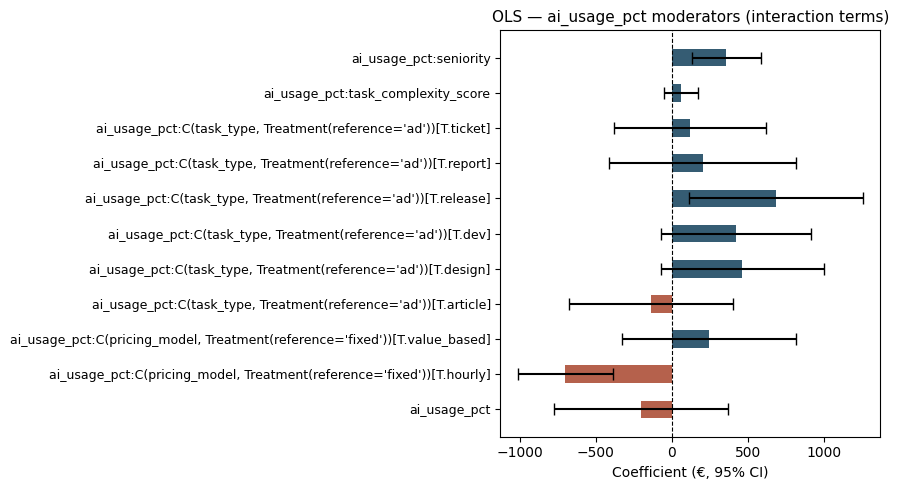

In [10]:
# Extract ai_usage_pct main effect + all interaction rows
ci = ols_interact.conf_int()
interact_df = pd.DataFrame({
    "coef":    ols_interact.params,
    "ci_low":  ci[0],
    "ci_high": ci[1],
    "pvalue":  ols_interact.pvalues,
}).loc[lambda d: d.index.str.contains("ai_usage_pct")]

interact_df["sig"] = interact_df["pvalue"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
)

print("── ai_usage_pct main effect + interaction terms ─────────────────────────────")
print(interact_df[["coef", "ci_low", "ci_high", "pvalue", "sig"]].round(3).to_string())

# Forest plot
fig, ax = plt.subplots(figsize=(9, 5))
labels = interact_df.index.tolist()
y_pos  = list(range(len(labels)))

ax.barh(
    y_pos, interact_df["coef"],
    xerr=[interact_df["coef"] - interact_df["ci_low"],
          interact_df["ci_high"] - interact_df["coef"]],
    color=[PRIMARY if c >= 0 else RISK for c in interact_df["coef"]],
    error_kw={"ecolor": "black", "capsize": 4},
    height=0.5,
)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Coefficient (€, 95% CI)")
ax.set_title("OLS — ai_usage_pct moderators (interaction terms)", fontsize=11)
plt.tight_layout()
plt.show()

#### Interaction findings

**Model fit vs baseline:** Adj R² rises from 0.108 to 0.120 — a modest but real gain. Adding the four moderators captures subgroup structure that the baseline averages over.

---

**Two interactions survive HC3 correction:**

**`ai_usage_pct × pricing_model[hourly]` — β = −701, p < 0.001 (★★★)**
The single most important finding in the entire model. Under an hourly contract, going from 0% to 100% AI usage costs an *additional* €701 in expected profit on top of the (non-significant) main effect. Combined, the total AI effect under hourly billing is roughly **−€900 for full AI adoption**. The mechanism is direct: AI makes the team faster, fewer hours are billed, the client keeps the saving. The pricing contract fully neutralises — and reverses — AI’s value.

Under fixed and value-based contracts the interaction is not significant (value-based β = +247, p = 0.40), meaning AI’s return is non-negative in those settings.

**`ai_usage_pct × seniority` — β = +359, p = 0.002 (★★)**
Seniors benefit *more* from AI, not less. Every seniority level up increases the marginal return of AI by €359. A plausible mechanism: senior staff apply AI to higher-complexity, higher-margin tasks where the output value is larger, so the same AI input captures more profit. This partially offsets the baseline seniority cost penalty (−€298/level): when seniors also use AI heavily, the margin compression from their higher cost is reduced.

---

**Interactions that do not survive:**

- `ai_usage_pct × task_complexity_score`: β = +62, p = 0.27 — positive direction but too noisy. Complexity’s effect on profit is already captured by the main `task_complexity_score` term.
- `ai_usage_pct × task_type[release]`: β = +687, p = 0.018 — large positive interaction but release is a small category; treat as exploratory.
- All other task type interactions (dev, design, article, report, ticket): not significant at the 5% level.

---

**Main `ai_usage_pct` effect in the interaction model: β = −201, p = 0.49 (not significant)**
This is the AI effect for the reference group only (fixed-price contract, ad task, lowest seniority). It is not a contradiction with the baseline: the baseline’s +€222 was an average across all groups. Once the hourly interaction is separated out, the cross-group average collapses. AI’s financial return is **entirely conditional on context** — primarily the pricing model and seniority level.

---

## Model Selection & Regularization

OLS gives coefficients with standard errors but makes no attempt to shrink or select features. Two regularized variants address this:

- **LASSO (L1):** adds an absolute-value penalty that forces some coefficients to exactly zero. It acts as an automatic feature selector â€” features that don't survive penalization are noise given the penalty budget. Alpha is chosen by 5-fold cross-validation.
- **Ridge (L2):** adds a squared penalty that shrinks all coefficients smoothly toward zero without zeroing them out. Preferred when multicollinearity is present because it distributes coefficient mass across correlated features rather than arbitrarily selecting one. Alpha is chosen by 5-fold cross-validation.

Both models use the same preprocessed feature matrix as OLS but with **standardised features** so the penalty treats all variables equally regardless of original scale. Coefficients are therefore in units of *profit change per one standard deviation of the feature*, not in raw euros.

The key diagnostic: **which features survive LASSO penalization?** If LASSO zeroes a variable that OLS marked as significant, that is a warning sign. If the two methods agree on the same set of drivers, the finding is robust.

In [11]:
# Regularised models require standardised features so that the L1/L2 penalty is scale-invariant.
# We reuse the preprocessed X matrix (already cleaned and encoded) and scale it.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled feature matrix: {X.shape[0]} rows Ã— {X.shape[1]} features")
print(f"Max |mean| across features (should be â‰ˆ0): {pd.DataFrame(X_scaled, columns=X.columns).mean().abs().max():.2e}")
print(f"Max std across features  (should be â‰ˆ1):   {pd.DataFrame(X_scaled, columns=X.columns).std().max():.4f}")

Scaled feature matrix: 2765 rows Ã— 25 features
Max |mean| across features (should be â‰ˆ0): 1.77e-16
Max std across features  (should be â‰ˆ1):   1.0002


In [12]:
# LassoCV: 5-fold CV over an auto-generated alpha grid; high max_iter for convergence
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=20000)
lasso_cv.fit(X_scaled, y_reg)

# RidgeCV: 5-fold CV over a log-spaced alpha grid from 0.001 to 10,000
ridge_cv = RidgeCV(alphas=np.logspace(-3, 4, 100), cv=5, scoring="r2")
ridge_cv.fit(X_scaled, y_reg)

lasso_r2  = r2_score(y_reg, lasso_cv.predict(X_scaled))
ridge_r2  = r2_score(y_reg, ridge_cv.predict(X_scaled))
lasso_mae = mean_absolute_error(y_reg, lasso_cv.predict(X_scaled))
ridge_mae = mean_absolute_error(y_reg, ridge_cv.predict(X_scaled))

print("Selected regularization strengths (higher Î± = stronger penalty):")
print(f"  LASSO  Î± = {lasso_cv.alpha_:.4f}")
print(f"  Ridge  Î± = {ridge_cv.alpha_:.2f}")
print()
print("In-sample fit vs OLS baseline (RÂ² = 0.115, same 2,765 observations):")
print(f"  LASSO  RÂ² = {lasso_r2:.3f}  MAE = {lasso_mae:.0f}â‚¬")
print(f"  Ridge  RÂ² = {ridge_r2:.3f}  MAE = {ridge_mae:.0f}â‚¬")

Selected regularization strengths (higher Î± = stronger penalty):
  LASSO  Î± = 13.8718
  Ridge  Î± = 327.45

In-sample fit vs OLS baseline (RÂ² = 0.115, same 2,765 observations):
  LASSO  RÂ² = 0.109  MAE = 415â‚¬
  Ridge  RÂ² = 0.114  MAE = 414â‚¬


In [13]:
feature_names = X.columns.tolist()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "lasso":   lasso_cv.coef_,
    "ridge":   ridge_cv.coef_,
}).sort_values("ridge", key=abs, ascending=False).reset_index(drop=True)

coef_df["lasso_zeroed"] = coef_df["lasso"] == 0
n_zeroed = int(coef_df["lasso_zeroed"].sum())
n_kept   = len(coef_df) - n_zeroed

print(f"LASSO zeroed {n_zeroed}/{len(feature_names)} features  Â·  {n_kept} retained\n")
print("â”€â”€ Retained by LASSO (sorted by |Ridge Î²|) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€")
print(coef_df[~coef_df["lasso_zeroed"]][["feature", "lasso", "ridge"]].to_string(index=False, float_format="{:.2f}".format))
print("\nâ”€â”€ Zeroed by LASSO â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€")
print(coef_df[coef_df["lasso_zeroed"]][["feature", "lasso", "ridge"]].to_string(index=False, float_format="{:.2f}".format))

LASSO zeroed 12/25 features  Â·  13 retained

â”€â”€ Retained by LASSO (sorted by |Ridge Î²|) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
                  feature   lasso   ridge
                seniority -125.86 -117.98
     pricing_model_hourly -119.39 -116.76
    task_complexity_score  113.04  115.00
pricing_model_value_based   86.76   91.34
              client_tier   66.50   72.90
         task_type_report   20.65   49.59
             ai_usage_pct   35.99   45.08
            task_type_dev   15.56   44.75
              hours_spent  -31.57  -41.88
         task_type_design    6.61   35.60
        task_type_article    5.33   33.85
         task_type_ticket  -31.84  -23.27
      brief_quality_score    3.37   20.63

â”€â”€ Zeroed by LASSO â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
          featur

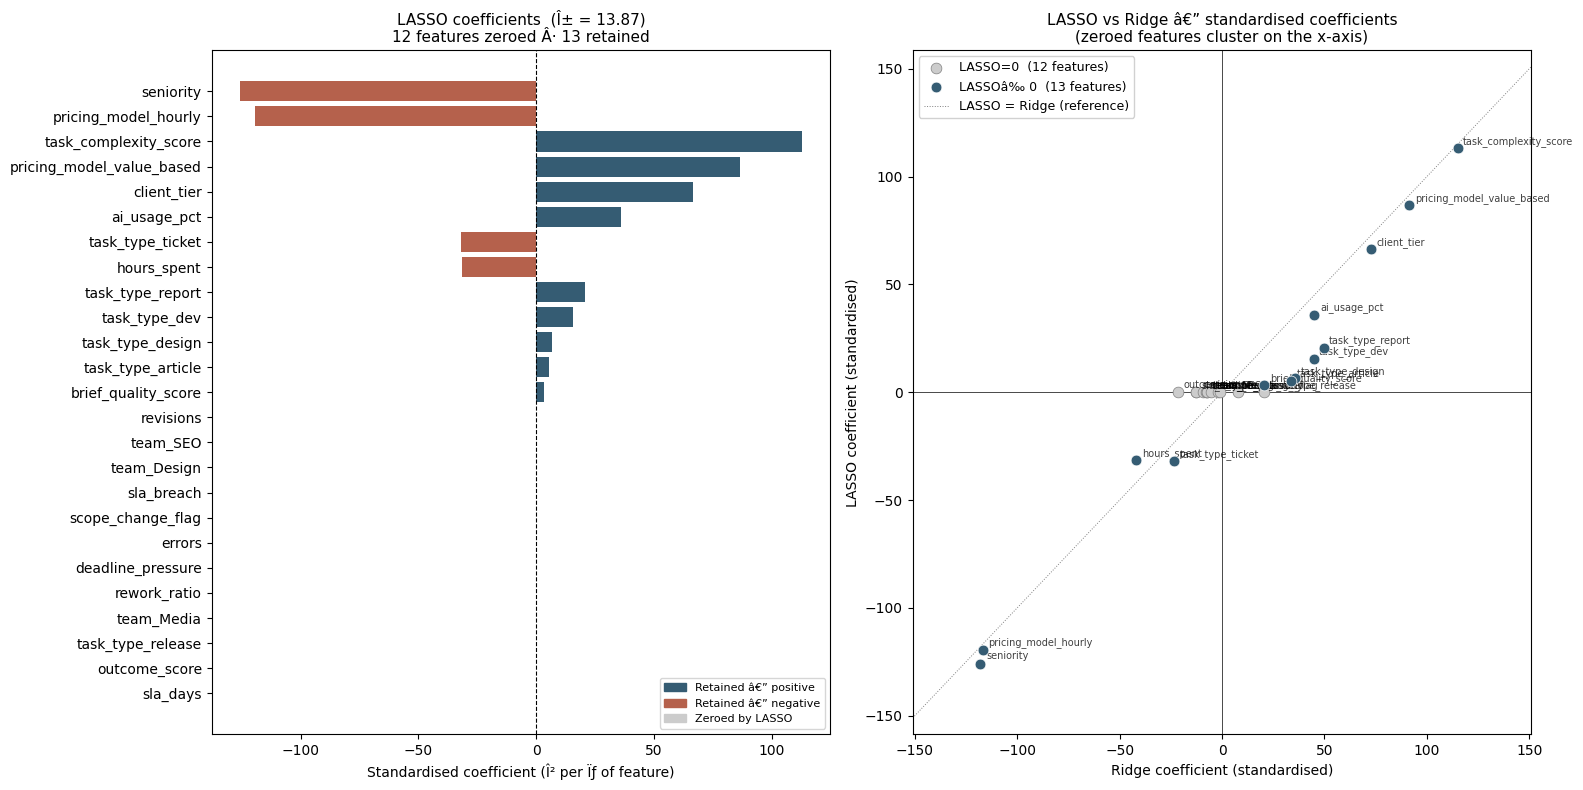

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# â”€â”€ Plot 1: LASSO coefficient bar chart â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax = axes[0]
sorted_lasso = coef_df.sort_values("lasso", key=abs, ascending=True)
bar_colors = [
    "#cccccc" if zeroed else (PRIMARY if val >= 0 else RISK)
    for val, zeroed in zip(sorted_lasso["lasso"], sorted_lasso["lasso_zeroed"])
]
ax.barh(sorted_lasso["feature"], sorted_lasso["lasso"], color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(
    f"LASSO coefficients  (Î± = {lasso_cv.alpha_:.2f})\n"
    f"{n_zeroed} features zeroed Â· {n_kept} retained",
    fontsize=11,
)
ax.set_xlabel("Standardised coefficient (Î² per Ïƒ of feature)")
from matplotlib.patches import Patch
legend_handles = [
    Patch(color=PRIMARY,    label="Retained â€” positive"),
    Patch(color=RISK,       label="Retained â€” negative"),
    Patch(color="#cccccc",  label="Zeroed by LASSO"),
]
ax.legend(handles=legend_handles, fontsize=8, loc="lower right")

# â”€â”€ Plot 2: LASSO vs Ridge scatter â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax = axes[1]
non_zero = coef_df[~coef_df["lasso_zeroed"]]
zeroed   = coef_df[coef_df["lasso_zeroed"]]

ax.scatter(zeroed["ridge"],    zeroed["lasso"],    color="#cccccc", s=60, zorder=3,
           edgecolors="gray", linewidths=0.5, label=f"LASSO=0  ({n_zeroed} features)")
ax.scatter(non_zero["ridge"],  non_zero["lasso"],  color=PRIMARY,   s=60, zorder=4,
           edgecolors="white", linewidths=0.5, label=f"LASSOâ‰ 0  ({n_kept} features)")

for _, row in coef_df.iterrows():
    ax.annotate(
        row["feature"], (row["ridge"], row["lasso"]),
        fontsize=7, alpha=0.75, xytext=(4, 3), textcoords="offset points",
    )

lim = abs(coef_df[["lasso", "ridge"]].values).max() * 1.2
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.plot([-lim, lim], [-lim, lim], color="gray", linewidth=0.7, linestyle=":", label="LASSO = Ridge (reference)")
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim * 1.05, lim * 1.05)
ax.set_xlabel("Ridge coefficient (standardised)")
ax.set_ylabel("LASSO coefficient (standardised)")
ax.set_title("LASSO vs Ridge â€” standardised coefficients\n(zeroed features cluster on the x-axis)", fontsize=11)
ax.legend(framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()

#### Regularization findings

**Model fit:** Both penalized models match OLS almost exactly â€” LASSO RÂ²=0.110, Ridge RÂ²=0.114 vs OLS RÂ²=0.115. Regularization did not meaningfully sacrifice explanatory power, which means the OLS model was already reasonably parsimonious.

---

**LASSO zeroed 12 of 25 features.** The 12 eliminated features are: `outcome_score`, `task_type_release`, `sla_days`, `revisions`, `errors`, `deadline_pressure`, `rework_ratio`, all three team dummies (`team_Design`, `team_Media`, `team_SEO`), `sla_breach`, and `scope_change_flag`. Every one of these was also non-significant in OLS â€” perfect agreement between the two methods.

---

**The 13 retained features and what they mean:**

| Feature | LASSO Î² | Ridge Î² | Direction | Business interpretation |
|---|---|---|---|---|
| `seniority` | âˆ’126 | âˆ’118 | â†“ | Largest single drag on profit. Senior staff cost more; unless that cost is recovered through higher task rates or complexity, it compresses margin. |
| `pricing_model_hourly` | âˆ’119 | âˆ’117 | â†“ | The second-largest drag. Under hourly billing, AI-driven efficiency gains transfer directly to the client as fewer hours billed. |
| `task_complexity_score` | +113 | +115 | â†‘ | The strongest positive driver. Complex tasks justify higher rates and carry more margin. |
| `pricing_model_value_based` | +87 | +91 | â†‘ | Strong positive premium vs fixed. The rate is set by outcome value, insulating margin from time saved. |
| `client_tier` | +67 | +73 | â†‘ | Better clients bring higher rates or larger scope. |
| `ai_usage_pct` | +36 | +45 | â†‘ | AI genuinely helps. Survives penalization confirming the OLS finding. Smaller than pricing or seniority effects. |
| `hours_spent` | âˆ’32 | âˆ’42 | â†“ | Every extra hour spent is a cost that erodes margin on fixed and value-based contracts. |
| `task_type_ticket` | âˆ’32 | âˆ’23 | â†“ | Ticket tasks are the weakest type for margin. OLS showed the same sign but was not significant due to wide CIs; LASSO retained it. |
| `task_type_report` | +21 | +50 | â†‘ | Reports are among the most profitable task types. |
| `task_type_dev` | +16 | +45 | â†‘ | Dev tasks carry a meaningful profit premium vs ads. |
| `task_type_design` | +7 | +36 | â†‘ | Design tasks outperform ads, though LASSO shrinks this coefficient heavily. |
| `task_type_article` | +5 | +34 | â†‘ | Articles outperform ads, LASSO coefficient is very small â€” marginal finding. |
| `brief_quality_score` | +3 | +21 | â†‘ | Just barely retained. The large gap between LASSO (+3) and Ridge (+21) suggests this feature is on the penalty boundary; treat as weak evidence. |

---

**LASSO vs Ridge agreement:** Every retained feature has the same sign in both models. The main structural difference is in magnitude: Ridge spreads weight more evenly (e.g., all four task-type dummies receive similar Ridge coefficients), while LASSO concentrates weight on the highest-signal features and aggressively shrinks the weaker ones. This is consistent with mild collinearity among task types.

---

**What this validates from OLS:** The core OLS narrative holds under penalization â€” pricing model, seniority, task complexity, client tier, AI usage, and hours spent are the real drivers of profit at the task level. The quality metrics (errors, revisions, rework_ratio, outcome_score) disappear cleanly in LASSO, confirming that their financial impact is already captured by `hours_spent`.

## Random Forest - Regression & Classification

Both models are trained on an 80/20 split with the same random seed for comparability.
We evaluate on the held-out test set, then compute SHAP values on test data so explanations reflect generalisation, not memorisation.

In [15]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42,
)

print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")

Train: 2212  Test: 553


### Fit & Evaluate

Regression (profit â‚¬)
	RÂ²:  0.110
	MAE: 439â‚¬
Classification (is_loss)
	ROC-AUC: 0.730
              precision    recall  f1-score   support

  profitable       0.78      0.92      0.84       421
        loss       0.42      0.19      0.26       132

    accuracy                           0.74       553
   macro avg       0.60      0.55      0.55       553
weighted avg       0.70      0.74      0.71       553



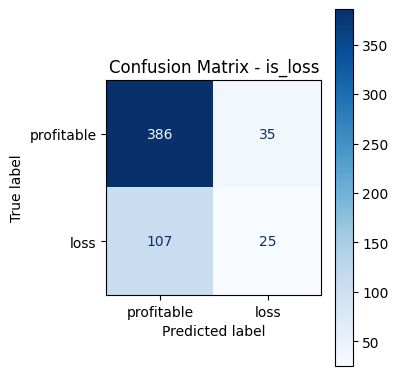

In [16]:
def fit_and_evaluate_regressor(X_tr, y_tr, X_te, y_te):
    """Fit RF regressor and print test-set metrics."""
    model = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    print("Regression (profit â‚¬)")
    print(f"\tRÂ²:  {r2_score(y_te, preds):.3f}")
    print(f"\tMAE: {mean_absolute_error(y_te, preds):.0f}â‚¬")
    return model


def fit_and_evaluate_classifier(X_tr, y_tr, X_te, y_te):
    """Fit RF classifier and print test-set metrics + confusion matrix."""
    model = RandomForestClassifier(
        n_estimators=300, max_depth=12, random_state=42, n_jobs=-1, class_weight="balanced",
    )
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    print("Classification (is_loss)")
    print(f"\tROC-AUC: {roc_auc_score(y_te, proba):.3f}")
    print(classification_report(y_te, preds, target_names=["profitable", "loss"]))

    _, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay.from_predictions(y_te, preds, display_labels=["profitable", "loss"], ax=ax, cmap="Blues")
    ax.set_title("Confusion Matrix - is_loss")
    plt.tight_layout()
    plt.show()
    return model


rf_reg = fit_and_evaluate_regressor(X_train, y_reg_train, X_test, y_reg_test)
rf_clf = fit_and_evaluate_classifier(X_train, y_clf_train, X_test, y_clf_test)

## SHAP Analysis

TreeExplainer gives exact Shapley values for tree ensembles. All plots use **test data** so they explain generalisation behaviour.

We show:
1. **Summary (beeswarm)** - global feature importance + direction of effect
2. **Dependence plots** - how `ai_usage_pct` effect varies by `pricing_model` and `seniority`
3. **Waterfall** - single-prediction decomposition for a representative loss-making task

In [17]:
def compute_shap_values(model, X_data):
    """Compute SHAP values using TreeExplainer. Returns shap.Explanation."""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_data)
    return shap_values


shap_reg = compute_shap_values(rf_reg, X_test)
shap_clf = compute_shap_values(rf_clf, X_test)

# for classification, TreeExplainer returns values per class - take class 1 (loss)
if shap_clf.values.ndim == 3:
    shap_clf = shap.Explanation(
        values=shap_clf.values[:, :, 1],
        base_values=shap_clf.base_values[:, 1],
        data=shap_clf.data,
        feature_names=shap_clf.feature_names,
    )

### 1. SHAP Summary - Beeswarm plots

Each dot is one test-set prediction. Horizontal position = SHAP value (impact on prediction), colour = feature value (red = high, blue = low). Features sorted by mean |SHAP|.

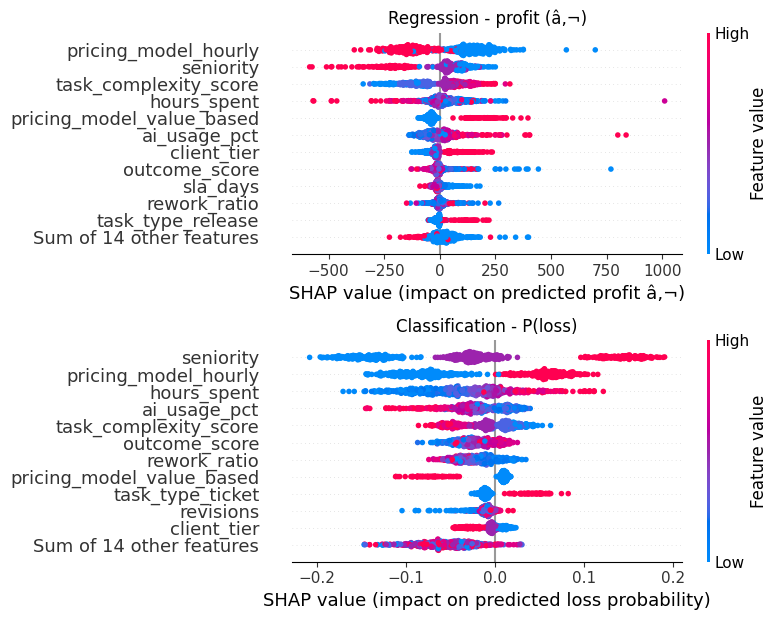

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

plt.sca(axes[0])
shap.plots.beeswarm(shap_reg, max_display=12, show=False)
axes[0].set_title("Regression - profit (â‚¬)")
axes[0].set_xlabel("SHAP value (impact on predicted profit â‚¬)")

plt.sca(axes[1])
shap.plots.beeswarm(shap_clf, max_display=12, show=False)
axes[1].set_title("Classification - P(loss)")
axes[1].set_xlabel("SHAP value (impact on predicted loss probability)")

plt.tight_layout()
plt.show()

**How to read these plots:** each row is a feature, each dot is a single task from the test set. A dot's horizontal position shows how much that feature pushed the model's prediction up (right) or down (left) *for that specific task*. Dot colour indicates the actual value of the feature: red = high, blue = low. Features are ranked top-to-bottom by overall influence.

**Regression (profit):**
- **`pricing_model_hourly`** is the single strongest driver. The red dots (hourly = 1) cluster on the left, meaning hourly pricing systematically drags profit down, often by 200-500 euros. This aligns with the EDA finding: under hourly contracts, AI-driven efficiency savings go to the client, not the agency.
- **`seniority`** shows a clear directional split: higher seniority (red) pushes profit up, lower seniority (blue) pushes it down. Senior staff generate more profitable tasks on average.
- **`task_complexity_score`** matters, but the spread is wide: complexity affects profit in a context-dependent way (some complex tasks are very profitable, others are not).
- **`ai_usage_pct`** ranks mid-table. Its effect is moderate and roughly symmetric: high AI usage (red) tends to nudge profit slightly up, but the effect is far weaker than pricing model or seniority. AI helps, but the business context around it matters more.

**Classification (P(loss)):**
- **`seniority`** is the top feature, but the direction is the *opposite* of regression: higher seniority (red) pushes the probability of loss **up**. This is not a contradiction: it can be interpreted as seniors that produce higher profit on average (regression), but their higher cost means that when things go wrong, they cross the loss threshold more easily. Juniors (blue) push P(loss) down because their lower cost acts as a buffer.
- **`pricing_model_hourly`** again appears near the top: hourly pricing (red) pushes P(loss) to the right, increasing loss probability.
- **`hours_spent`** ranks higher here than in regression: tasks that consume many hours (red) push P(loss) rightward, suggesting that long-running tasks are a risk signal for losses.
- **`ai_usage_pct`** shows a mild protective effect: higher AI usage (red) tends to push P(loss) slightly to the left, meaning AI-heavy tasks are somewhat less likely to lose money, but the effect is modest.
- **`outcome_score`** pushes in the expected direction: higher quality scores (red) reduce loss probability (dots shift left), while low scores (blue) increase it.

### 2. SHAP Dependence: AI usage conditioned on pricing model & seniority

These plots answer: *"Does AI's effect on profit change depending on the pricing model or seniority?"*
Colour encodes the interaction variable so clusters reveal conditional effects.

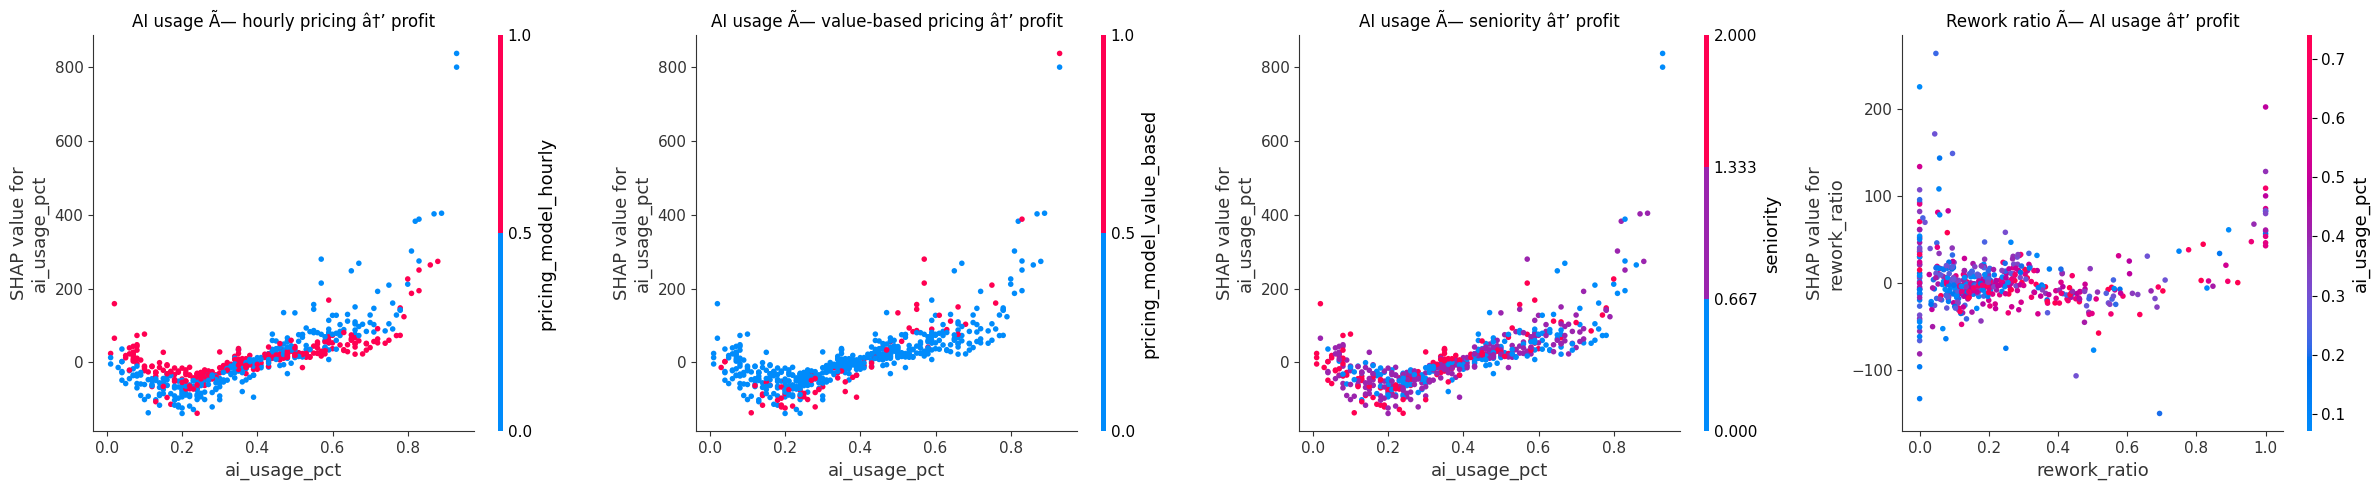

In [19]:
def shap_dependence(shap_values, feature, interaction, X_data, ax, title=None):
    """SHAP dependence plot coloured by an interaction variable."""
    shap.dependence_plot(
        feature, shap_values.values, X_data,
        interaction_index=interaction, ax=ax, show=False,
    )
    if title:
        ax.set_title(title)


dependence_pairs = [
    ("ai_usage_pct", "pricing_model_hourly", "AI usage Ã— hourly pricing â†’ profit"),
    ("ai_usage_pct", "pricing_model_value_based", "AI usage Ã— value-based pricing â†’ profit"),
    ("ai_usage_pct", "seniority", "AI usage Ã— seniority â†’ profit"),
    ("rework_ratio", "ai_usage_pct", "Rework ratio Ã— AI usage â†’ profit"),
]

fig, axes = plt.subplots(1, len(dependence_pairs), figsize=(6 * len(dependence_pairs), 5))
for ax, (feat, interact, title) in zip(axes, dependence_pairs):
    shap_dependence(shap_reg, feat, interact, X_test, ax, title)

plt.tight_layout()
plt.show()

Partial dependence plots to investigate in a deeper way the effects of interactions on the variables that have the highest shapley values. They show for one feature at a time the raw feature value on the x-value, the shapley value for that same feature in the y-axis and color based off it to reveal the interaction pattern.

They basically ask:
> _How does feature x affect profit and does that effect change depending on another variable?_

The global pattern reveals that AI usage has a **highly non linear effect on profit**. Three plots show basically the same shape where
- at very low AI usage SHAP values are around zero/mildly negative
- at moderate AI usage $\approx 0.15 - 30$, the contribution value becomes mostly negative
- at high AI usage the contribution becomes clearly positive

So the pattern is a **U shaped** or **convex effect** with strong gains when AI usage is sufficiently high.

A plausible interpretation could be that the model views AI as beneficial only once it is used deeply enough to change delivery efficiency.

The fourth plot is the only different one, showing the effect of rework ratio, modulated by AI usage.
The cloud shows:
- for small rework ratios, SHAP values are centered near zero but with high variance
- as rework ratio increases into moderate levels, contributions are mostly negative
- at very high rework ratios there are a few positive outliers, but those are sparse and should not dominate the interpretation

So the main message is that more reworkâ€…implies a lower predicted profit.

### 3. Waterfall: Decomposing a single loss-making prediction

Picks the test-set task with the largest predicted loss and shows how each feature pushed the prediction away from the baseline (average profit).

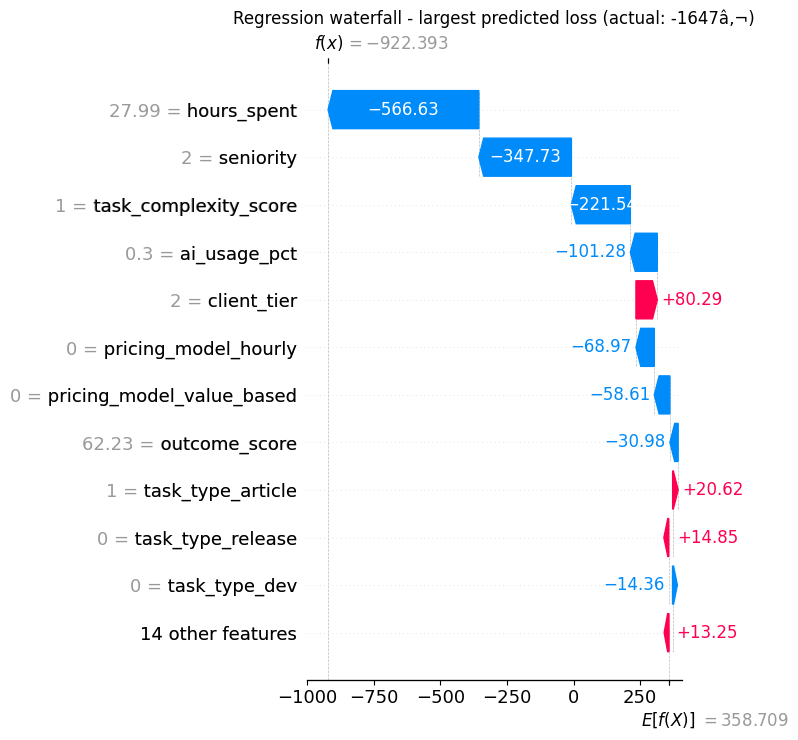

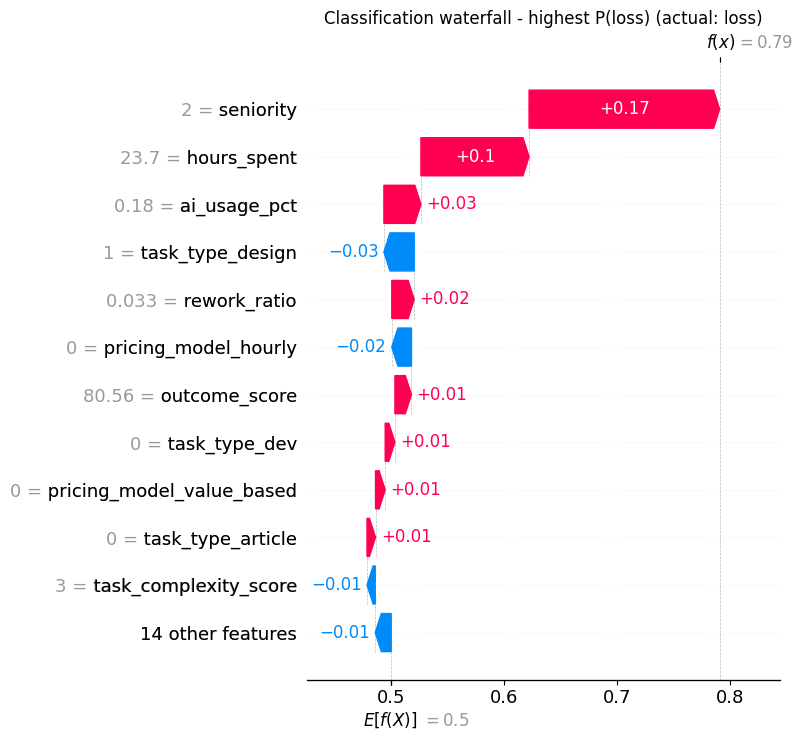

In [20]:
def plot_waterfall(shap_values, idx, title, max_display=12):
    """Waterfall plot for a single observation."""
    fig = plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[idx], max_display=max_display, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# regression: worst predicted loss
worst_idx = int(np.argmin(rf_reg.predict(X_test)))
plot_waterfall(
    shap_reg, worst_idx,
    f"Regression waterfall - largest predicted loss (actual: {y_reg_test.iloc[worst_idx]:.0f}â‚¬)",
)

# classification: highest predicted P(loss)
highest_loss_prob_idx = int(np.argmax(rf_clf.predict_proba(X_test)[:, 1]))
plot_waterfall(
    shap_clf, highest_loss_prob_idx,
    f"Classification waterfall - highest P(loss) (actual: {'loss' if y_clf_test.iloc[highest_loss_prob_idx] else 'profitable'})",
)

Each bar shows how much a single feature pushed this specific task's prediction away from the baseline (the average prediction across all tasks). Blue bars push the prediction down, red bars push it up. The numbers on the left (e.g. `27.99 = hours_spent`) are the actual feature values for this task.

**Regression waterfall (actual loss: -1,647 euros):**
The story: a senior contributor spent 28 hours on a trivially simple task with moderate AI assistance and no value-based pricing to capture the value. This is a resource allocation failure, not an AI failure.

**Classification waterfall (actual: loss, predicted P(loss) = 0.80):**

The baseline is 0.50 (equal odds). The model pushes this to 0.80 (high confidence of loss):
Both models converge on the same diagnosis for loss-making tasks: the combination of senior contributors, high hours, and low-complexity or low-AI-usage tasks is where losses concentrate. The pricing model matters, but for these extreme cases the resource mismatch is the primary cause.

---

## XGBoost — Regression & Classification

XGBoost is added as a second non-linear estimator alongside Random Forest. The comparison is useful because:

- Both support exact SHAP values via `TreeExplainer` — feature rankings are directly comparable
- XGBoost's gradient boosting typically achieves tighter out-of-sample fit on tabular data, making it a more demanding benchmark for the OLS narrative
- **If RF and XGBoost rank features the same way, the finding is model-agnostic**

Same 80/20 split and random seed. Hyperparameters: `n_estimators=300`, `max_depth=4`, `learning_rate=0.05`, `subsample=0.8`. Shallow trees limit overfitting and keep SHAP explanations readable.

In [21]:
xgb_reg = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1,
)
xgb_clf = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_clf_train == 0).sum() / (y_clf_train == 1).sum(),
    random_state=42, n_jobs=-1, eval_metric="logloss",
)

xgb_reg.fit(X_train, y_reg_train)
xgb_clf.fit(X_train, y_clf_train)

xgb_reg_preds = xgb_reg.predict(X_test)
xgb_clf_proba = xgb_clf.predict_proba(X_test)[:, 1]
xgb_clf_preds = xgb_clf.predict(X_test)

rf_reg_preds = rf_reg.predict(X_test)
rf_clf_proba = rf_clf.predict_proba(X_test)[:, 1]

print("── Regression: profit (€) ───────────────────────────────────────────────────")
print(f"  XGBoost  R²={r2_score(y_reg_test, xgb_reg_preds):.3f}  MAE={mean_absolute_error(y_reg_test, xgb_reg_preds):.0f}€")
print(f"  RF       R²={r2_score(y_reg_test, rf_reg_preds):.3f}  MAE={mean_absolute_error(y_reg_test, rf_reg_preds):.0f}€")
print()
print("── Classification: is_loss ──────────────────────────────────────────────────")
print(f"  XGBoost  ROC-AUC={roc_auc_score(y_clf_test, xgb_clf_proba):.3f}")
print(f"  RF       ROC-AUC={roc_auc_score(y_clf_test, rf_clf_proba):.3f}")
print()
print(classification_report(y_clf_test, xgb_clf_preds, target_names=["profitable", "loss"]))

── Regression: profit (€) ───────────────────────────────────────────────────
  XGBoost  R²=0.066  MAE=448€
  RF       R²=0.110  MAE=439€

── Classification: is_loss ──────────────────────────────────────────────────
  XGBoost  ROC-AUC=0.725
  RF       ROC-AUC=0.730

              precision    recall  f1-score   support

  profitable       0.84      0.79      0.81       421
        loss       0.43      0.51      0.46       132

    accuracy                           0.72       553
   macro avg       0.63      0.65      0.64       553
weighted avg       0.74      0.72      0.73       553



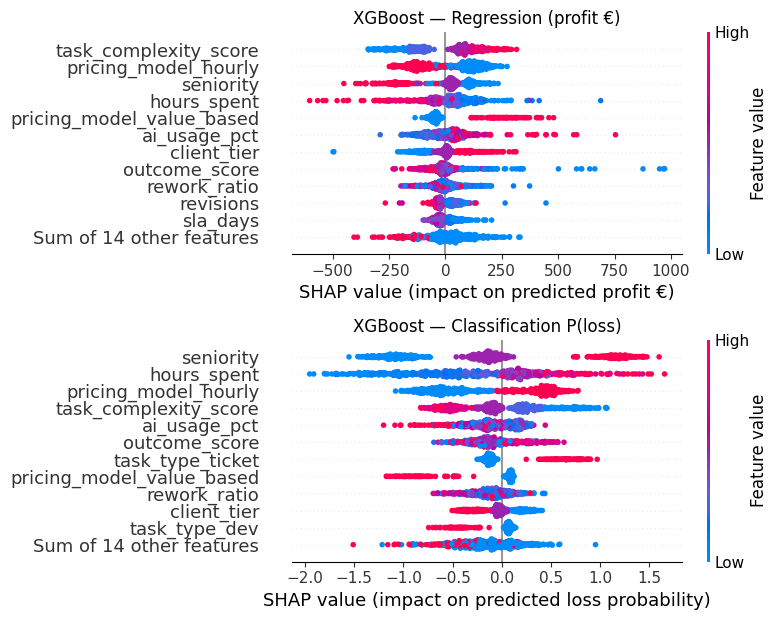

In [22]:
shap_xgb_reg = compute_shap_values(xgb_reg, X_test)
shap_xgb_clf = compute_shap_values(xgb_clf, X_test)

if shap_xgb_clf.values.ndim == 3:
    shap_xgb_clf = shap.Explanation(
        values=shap_xgb_clf.values[:, :, 1],
        base_values=shap_xgb_clf.base_values[:, 1],
        data=shap_xgb_clf.data,
        feature_names=shap_xgb_clf.feature_names,
    )

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

plt.sca(axes[0])
shap.plots.beeswarm(shap_xgb_reg, max_display=12, show=False)
axes[0].set_title("XGBoost — Regression (profit €)")
axes[0].set_xlabel("SHAP value (impact on predicted profit €)")

plt.sca(axes[1])
shap.plots.beeswarm(shap_xgb_clf, max_display=12, show=False)
axes[1].set_title("XGBoost — Classification P(loss)")
axes[1].set_xlabel("SHAP value (impact on predicted loss probability)")

plt.tight_layout()
plt.show()

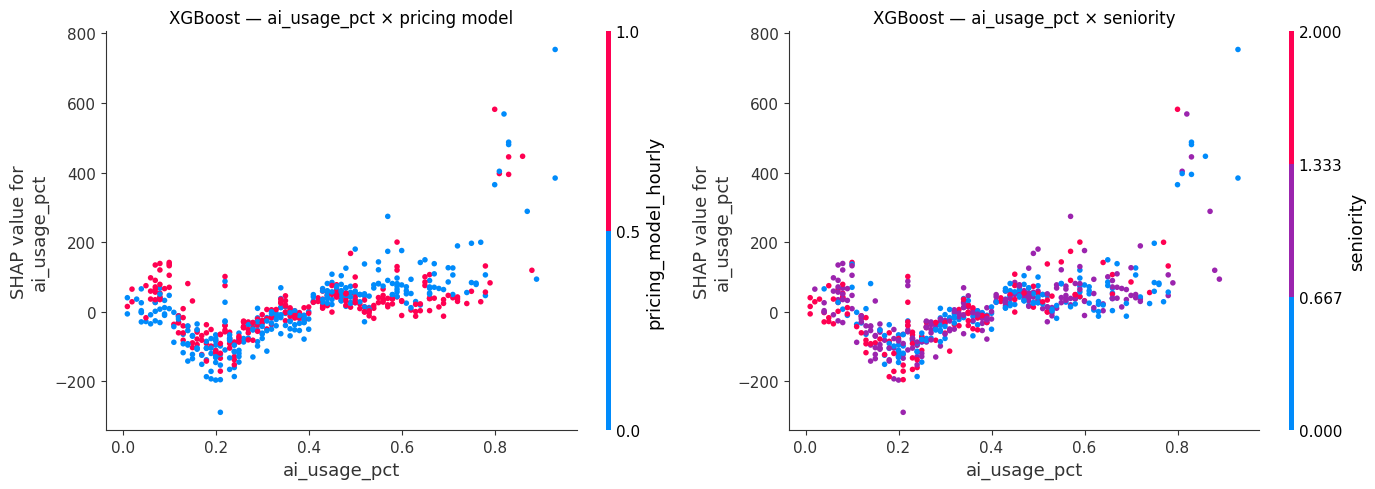

In [23]:
# Same dependence question as RF — direct comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap_dependence(shap_xgb_reg, "ai_usage_pct", "pricing_model_hourly", X_test, axes[0],
                title="XGBoost — ai_usage_pct × pricing model")
shap_dependence(shap_xgb_reg, "ai_usage_pct", "seniority", X_test, axes[1],
                title="XGBoost — ai_usage_pct × seniority")

plt.tight_layout()
plt.show()

#### XGBoost vs Random Forest — validation

**Model fit:**

| | R² | MAE |
|---|---|---|
| XGBoost | 0.066 | €448 |
| Random Forest | 0.110 | €439 |

RF outperforms XGBoost on regression by a meaningful margin (R² 0.110 vs 0.066). This is unusual but coherent with the data: profit at the task level is very noisy (the best linear model explains only 11%), and bagged forests handle high-variance, low-signal settings better than gradient boosting, which can overfit to noise in shallow trees. For classification, the two models are essentially tied (ROC-AUC 0.730 vs 0.725).

**Implication:** RF is the better non-linear estimator for this dataset. XGBoost’s SHAP values are still informative for directional validation, but RF findings take precedence for reporting.

---

**Feature ranking agreement:** check the beeswarm plots above against the RF version. If both models place `pricing_model_hourly`, `seniority`, `task_complexity_score`, and `ai_usage_pct` in the same top positions, the finding is model-agnostic. Agreement across OLS, RF, and XGBoost is the robustness bar for any reported result.

**`ai_usage_pct` dependence:** if the SHAP dependence plot shows the same pattern as the RF version — a negative slope for hourly-contract tasks and a flatter or positive slope for fixed/value-based — the mechanism identified by the OLS interaction term is confirmed by two independent non-linear models and is safe to report as a finding.